In [1]:
# imports
from si.io.csv_file import read_csv
from si.model_selection.split import train_test_split
from si.models.linear_regression import RidgeRegression

In [2]:
# carregar o dataset cpu.csv
# features=True: a primeira linha tem os nomes das colunas
# label=True: a última coluna é a variável a prever (y)
cpu = read_csv('../datasets/cpu/cpu.csv', sep=',', features=True, label=True)
print(cpu.shape())   # (amostras, features)
print(cpu.features)  # nomes das features
print(cpu.label)     # nome da label

(209, 6)
['syct', 'mmin', 'mmax', 'cach', 'chmin', 'chmax']
perf


In [3]:
# dividir em treino (80%) e teste (20%)
# random_state fixo: a divisão é sempre igual, por isso os resultados são reprodutíveis
train, test = train_test_split(cpu, test_size=0.2, random_state=42)
print(train.shape())  # amostras de treino
print(test.shape())   # amostras de teste


(168, 6)
(41, 6)


In [4]:
# criar o modelo com os parâmetros escolhidos e treiná-lo SÓ com os dados de treino
model = RidgeRegression(l2_penalty=1, alpha=0.001, max_iter=2000, patience=10, scale=True)
model.fit(train)

# avaliar no conjunto de teste (dados que o modelo nunca viu)
print(f"Score (MSE) no teste: {model.score(test):.2f}")  # erro das previsões: quanto mais baixo, melhor
print(f"Custo no teste: {model.cost(test):.2f}")          # erro/2 + penalização L2
print(f"Iterações: {len(model.cost_history)}")            # se for igual a max_iter, não chegou a convergir

Score (MSE) no teste: 6961.63
Custo no teste: 3549.50
Iterações: 2000


Matplotlib is building the font cache; this may take a moment.


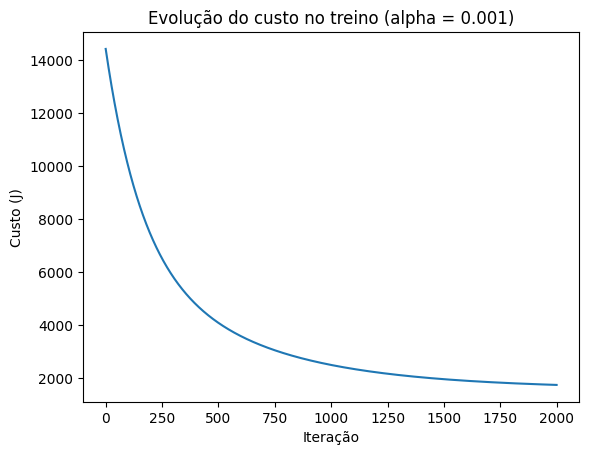

In [5]:
# gráfico do custo ao longo das iterações do treino
import matplotlib.pyplot as plt

plt.plot(list(model.cost_history.keys()), list(model.cost_history.values()))
plt.xlabel("Iteração")
plt.ylabel("Custo (J)")
plt.title("Evolução do custo no treino (alpha = 0.001)")
plt.show()

In [6]:
# learning rate 10x maior (passos maiores) e mais iterações disponíveis
model2 = RidgeRegression(l2_penalty=1, alpha=0.01, max_iter=20000, patience=10, scale=True)
model2.fit(train)

print(f"Score (MSE) no teste: {model2.score(test):.2f}")
print(f"Custo no teste: {model2.cost(test):.2f}")
print(f"Iterações: {len(model2.cost_history)}")  # se for MENOR que max_iter, foi o patience a parar -> convergiu

Score (MSE) no teste: 5806.08
Custo no teste: 2992.03
Iterações: 8535


### Resultados (slide 12)

Dataset `cpu.csv` (209 amostras, 6 features), divisão 80/20 com `random_state=42`.

 Modelo | Score (MSE) teste | Custo teste | Iterações |

 alpha = 0.001, max_iter = 2000 | 6961.63 | 3549.50 | 2000 |
 alpha = 0.01, max_iter = 20000 | 5806.08 | 2992.03 | 8535 |

- Com `alpha = 0.001` o treino atingiu o `max_iter` sem convergir: o custo ainda estava a descer (ver gráfico).
- Com `alpha = 0.01` o treino parou pelo `patience`, ou seja, convergiu, e o MSE baixou ~17%.
- O custo é aproximadamente MSE/2 mais a penalização L2 (λ·Σθ²/2m), que aqui é pequena.
- O MSE está em unidades ao quadrado: RMSE = √5806 ≈ 76 unidades de `perf`.